# 04 — Ablation: погода vs календарь vs лаги

**Запуск:** `python -m src.analysis.ablation_study` (если JSON устарел).  
**Смысл:** partial correlation погоды при контроле часа/дня; MAE моделей с разными наборами признаков.

In [4]:
# Ablation: погода vs календарь vs лаги
import json
import pandas as pd
from pathlib import Path

# Сначала: python -m src.analysis.ablation_study
ab = json.loads(Path("../artifacts/ablation_metrics.json").read_text(encoding="utf-8"))
pd.DataFrame([{"model": k, **v} for k, v in ab["models"].items()]).sort_values("mae")


,model,mae,rmse,smape
5,full_boosting,258.759473,485.995143,0.149958
4,lags_calendar_boosting,267.978467,513.022910,0.146726
6,ridge_full,587.365709,825.103121,0.446212
0,seasonal_naive_24h,889.329073,1277.340445,0.438565
3,calendar_only_boosting,1328.180422,1804.816862,0.533846
2,weather_only_boosting,1393.400643,1768.167364,0.699925
1,seasonal_naive_168h,1781.715976,2611.479283,0.646522


In [5]:
partial = pd.read_csv("../artifacts/partial_correlations.csv")
partial


,feature,pearson_raw,partial_vs_calendar
0,temperature_2m,0.516728,0.433369
1,precipitation,-0.095344,-0.135109
2,wind_speed_10m,0.122864,-0.053399
3,relative_humidity_2m,-0.469926,-0.177668
4,weather_code,-0.128396,-0.233031


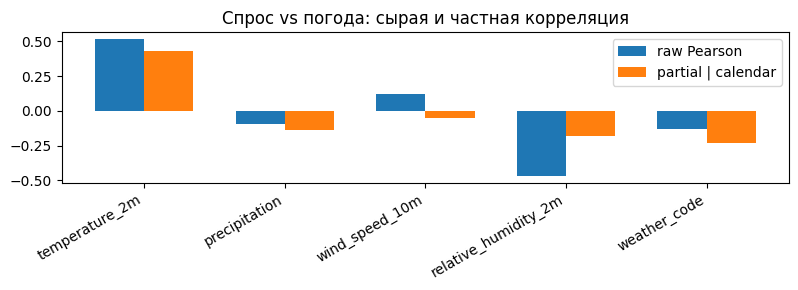

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 3))
x = range(len(partial))
w = 0.35
ax.bar([i - w/2 for i in x], partial["pearson_raw"], width=w, label="raw Pearson")
ax.bar([i + w/2 for i in x], partial["partial_vs_calendar"], width=w, label="partial | calendar")
ax.set_xticks(list(x))
ax.set_xticklabels(partial["feature"], rotation=30, ha="right")
ax.legend()
ax.set_title("Спрос vs погода: сырая и частная корреляция")
plt.tight_layout()
plt.show()
